## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [522]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [523]:
job_id = 72#int(sys.argv[1])

In [524]:
in_dir = project_dir / "results"
# out_dir = project_dir / "results" / "data_map"
#
# if not os.path.exists(out_dir):
#     os.makedirs(out_dir)

In [525]:
# load tile
# df_tile_mean = pickle.load(open(project_dir / "data" / "df_tile_mean", "rb"))
# xy_tile_all = df_tile_mean.values

# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [526]:
# FULL PILOT BATCH: 10 pi_level, 6 traj for one mouse x 2 + 5 random trajectories (170 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse_3 = [((1,3,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
job_list_mouse_4 = [((1,4,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch_optmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_optmap)

170

In [527]:
# RANDOM MAP BATCH: 10 pi_level, 2 mice x 5 random maps + 5 random trajectories x 5 random maps (350 jobs)
traj_seed_list = np.arange(5)
map_seed_list = np.arange(5)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,traj_seed,-1), pi_lev, map_seed) for pi_lev in pi_level_list for traj_seed in traj_seed_list for map_seed in map_seed_list]
job_list_mouse_3 = [((1,3,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]
job_list_mouse_4 = [((1,4,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]

# pack
job_batch_randmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_randmap)

350

## LOCAL PARAMETERS

In [528]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

## PREP
### setting up belief distribution propagation

In [529]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)
xy_tile_all = np.array([(hex_0_grid[y,x], hex_1_grid[y,x]) for (x,y), s in xy_s_dict.items()])

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

### bit per edge

In [530]:
# job_selected = [x for x,((y,z,w),u,v) in job_batch_randmap.items() if y==1]
# out_dir = project_dir / "results" / "data_randmap"
# [pickle.load(open(out_dir / f"dat_map_{job_batch_randmap[job_id]}", "rb"))[0] for job_id in job_selected]

In [531]:
job_batch_optmap

{1: ((0, 0, -1), 0),
 2: ((0, 1, -1), 0),
 3: ((0, 2, -1), 0),
 4: ((0, 3, -1), 0),
 5: ((0, 4, -1), 0),
 6: ((0, 0, -1), 10),
 7: ((0, 1, -1), 10),
 8: ((0, 2, -1), 10),
 9: ((0, 3, -1), 10),
 10: ((0, 4, -1), 10),
 11: ((0, 0, -1), 20),
 12: ((0, 1, -1), 20),
 13: ((0, 2, -1), 20),
 14: ((0, 3, -1), 20),
 15: ((0, 4, -1), 20),
 16: ((0, 0, -1), 30),
 17: ((0, 1, -1), 30),
 18: ((0, 2, -1), 30),
 19: ((0, 3, -1), 30),
 20: ((0, 4, -1), 30),
 21: ((0, 0, -1), 40),
 22: ((0, 1, -1), 40),
 23: ((0, 2, -1), 40),
 24: ((0, 3, -1), 40),
 25: ((0, 4, -1), 40),
 26: ((0, 0, -1), 50),
 27: ((0, 1, -1), 50),
 28: ((0, 2, -1), 50),
 29: ((0, 3, -1), 50),
 30: ((0, 4, -1), 50),
 31: ((0, 0, -1), 60),
 32: ((0, 1, -1), 60),
 33: ((0, 2, -1), 60),
 34: ((0, 3, -1), 60),
 35: ((0, 4, -1), 60),
 36: ((0, 0, -1), 70),
 37: ((0, 1, -1), 70),
 38: ((0, 2, -1), 70),
 39: ((0, 3, -1), 70),
 40: ((0, 4, -1), 70),
 41: ((0, 0, -1), 80),
 42: ((0, 1, -1), 80),
 43: ((0, 2, -1), 80),
 44: ((0, 3, -1), 80),
 4

In [532]:
job_id = 93 # 105,46; 99,41; 93,36
mapsize = 39 # 39,41; 68,71

# load job
job = job_batch_optmap[job_id]
out_dir = project_dir / "results" / "data_optmap"
score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(out_dir / f"dat_map_{job}", "rb"))

# load traj
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]

# get map
map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
mapsize_iter = [len(x) for x in map_iter]
iter_select = mapsize_iter.index(mapsize)
# map_dict = {len(x): x for x in map_iter}
map = map_iter[iter_select]
mask_map = np.zeros_like(sh_dz_arr, dtype=int)
mask_map[*e_sh_arr[map].T] = 1
n_edges_map = mask_map.sum(1)

# get diffusion radius, tile locality
score = score_iter_full[iter_select]
score_map = score_map_iter_full[iter_select]
# sigma_local = 1/(2*np.pi)**.5/.7
# sigma_local = 1
d_mat_tile = ((xy_tile_all[:,None] - xy_tile_all[None,:,:])**2).sum(-1)**.5
# L_tile = np.exp(-d_mat_tile**2/(2*sigma_local**2))#[:,s_top]
# L_tile[np.diag_indices(len(L_tile))] = 0
# L_tile = L_tile / L_tile.sum(-1, keepdims=True)
# L_tile = np.ones_like(L_tile) / len(L_tile)

# # get local tile ambiguity
# sh_dz_arr_map = np.zeros_like(sh_dz_arr) - 1
# sh_dz_arr_map[*e_sh_arr[map].T] = sh_dz_arr[*e_sh_arr[map].T]
# sh_dz_roll_map = np.stack([np.roll(sh_dz_arr_map, x, axis=1) for x in range(6)], axis=1)
# d_mat_dz = np.abs(sh_dz_roll_map[:,None,:,:] - sh_dz_arr_map[None,:,None,:]).sum(-1).min(-1)
# A = d_mat_dz==0
# A_local = L_tile * A
# A_local = A_local / A_local.sum(-1, keepdims=True)

# print
score, sigma_local

(0.217196, 0.5699175434306182)

In [533]:
def f(X, s, score):
    return np.exp(-((xy_tile_all - xy_tile_all[s])**2).sum(1) / (2*X**2)).sum() - 1/score

sigma_tile = np.array([root(f, 0.4, args=(s, score)).x[0] for s, score in enumerate(score_map)])
L_tile = np.exp(-d_mat_tile**2/(2*sigma_tile[:, None]**2))
L_tile = L_tile / L_tile.sum(-1, keepdims=True)

In [534]:
# get local tile ambiguity
sh_dz_arr_map = np.zeros_like(sh_dz_arr) + np.nan
sh_dz_arr_map[*e_sh_arr[map].T] = sh_dz_arr[*e_sh_arr[map].T]
sh_dz_roll_map = np.stack([np.roll(sh_dz_arr_map, x, axis=1) for x in range(6)], axis=1)

# d_tensor = np.abs(sh_dz_roll_map[:,None,:,:] - sh_dz_arr_map[None,:,None,:])
# d_tensor = np.abs(sh_dz_roll_map[:,None,:,:] - sh_dz_arr[None,:,None,:])
# mask_ = sh_dz_arr_map.sum(-1)!=-600
# mask_mat = mask_[:,None] * mask_[None,:]
# d_mat_dz = np.nansum(np.abs(sh_dz_roll_map[:,None,:,:] - sh_dz_arr[None,:,None,:]), axis=-1).min(-1)
d_mat_dz = np.nansum(np.abs(sh_dz_arr[:,None,None,:] - sh_dz_roll_map[None,:,:,:]), axis=-1).min(-1)

# d_mat_dz = np.nansum(np.abs(sh_dz_roll_map[:,None,:,:] - sh_dz_arr_map[None,:,None,:]), axis=-1).min(-1)
# A = (d_mat_dz * mask_mat) == 0
A = (d_mat_dz==0)#[:,s_top]
A_local = L_tile * A
# A_local = A_local / A_local.sum(-1, keepdims=True)

In [535]:
p = L_tile[s_top,:]
q = L_tile[s_top,:] * A[s_top,:]

In [536]:
p.max(1).mean()

0.2171955987321088

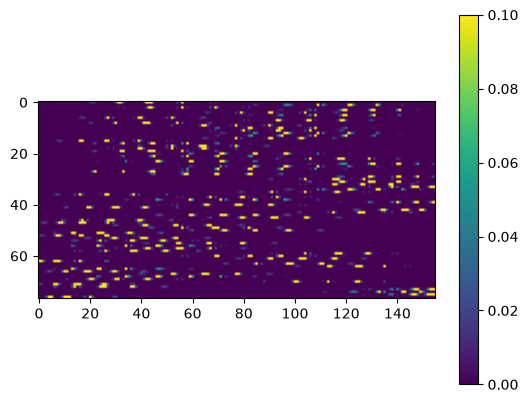

In [537]:
plt.imshow(q, vmax=.1)
plt.colorbar()

8.692331893429776

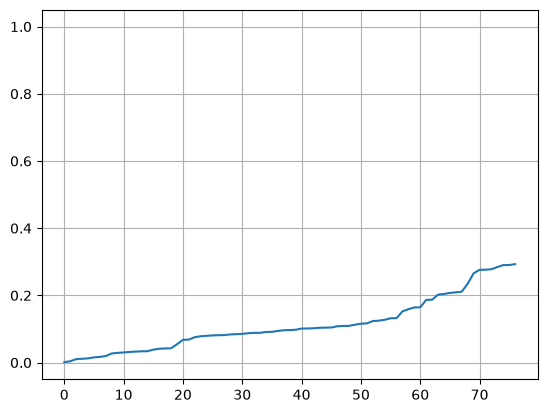

In [538]:
plt.plot(np.sort(-np.log(q.sum(1)) / (-np.log(p.max(1)))))
plt.ylim([-.05, 1.05])
plt.grid()
(-np.log(q.sum(1)) / (-np.log(p.max(1)))).sum()

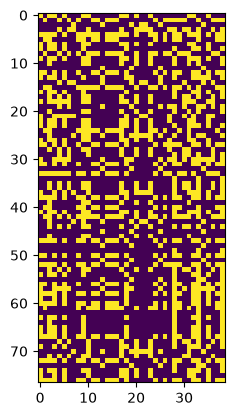

In [434]:
plt.imshow(A[s_top,:][:,e_sh_arr[map][:,0]])

In [420]:
nbrs = [s_nbr_dict[x] for x in e_sh_arr[map][:,0]]
n_nbrs = np.array([len([y for y in x if y in s_top]) for x in nbrs])
n_nbrs, np.mean(n_nbrs)

(array([3, 3, 5, 5, 3, 6, 3, 4, 6, 6, 6, 4, 6, 6, 6, 4, 6, 5, 5, 6, 4, 3,
        4, 4, 6, 2, 6, 1, 4, 3, 4, 2, 4, 2, 0, 1, 3, 0, 0]),
 3.871794871794872)

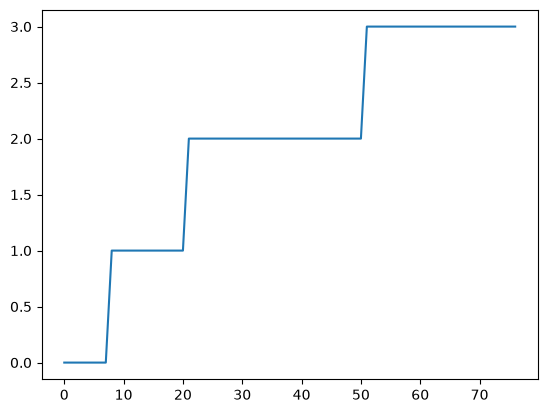

In [421]:
nbrs = [s_nbr_dict[x] for x in s_top]
n_nbrs = np.array([len([y for y in x if y in e_sh_arr[map][:,0]]) for x in nbrs])
n_nbrs, np.mean(n_nbrs), np.percentile(n_nbrs,50)
plt.plot(np.sort(n_nbrs))

In [363]:
len([x for x in e_sh_arr[map][:,0] if x in s_top]), np.isin(map, eid_wall).sum(), np.isin (e_sh_arr[map][:,0], set([x for x,y in sh_wall])).sum()

(11, 0, 0)

In [364]:
s_top_map = [x for x in e_sh_arr[map][:,0] if x in s_top]
nbrs = [s_nbr_dict[x] for x in s_top_map]
n_nbrs = np.array([len([y for y in x if y in e_sh_arr[map][:,0]]) for x in nbrs])
n_nbrs, np.mean(n_nbrs)

(array([1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]), 0.6363636363636364)

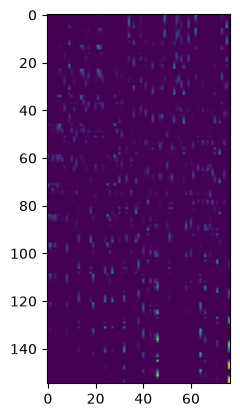

In [37]:
plt.imshow(A_local)

In [38]:
# pp = w_mat_tile[77]
# pp = np.ones_like(w_mat_tile[77]) / len(w_mat_tile[77])
en_tile_max = (-L_tile * np.log(L_tile + 1e-16)).sum(1)
n_eff = np.exp(en_tile_max)
n_eff[123]

8.242939526852883

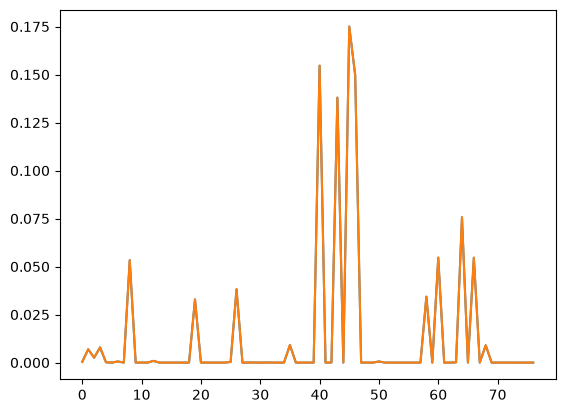

In [39]:
plt.plot(L_tile[112])
plt.plot(A_local[112])

In [40]:
en_tile = (-A_local * np.log(A_local + 1e-16)).sum(1)
n_amb = np.exp(en_tile)
n_amb[123]

3.2046457698638386

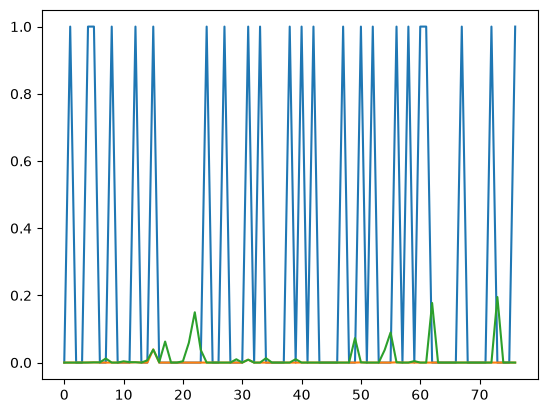

In [41]:
plt.plot(A[15])
plt.plot(A_local[15])
plt.plot(L_tile[15])

In [42]:
specmap = 1 - en_tile / en_tile_max
infomap = specmap/(n_edges_map+1e-6)

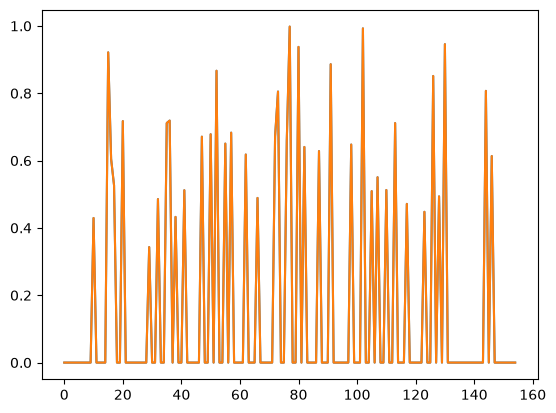

In [43]:
plt.plot(specmap)
plt.plot(infomap)

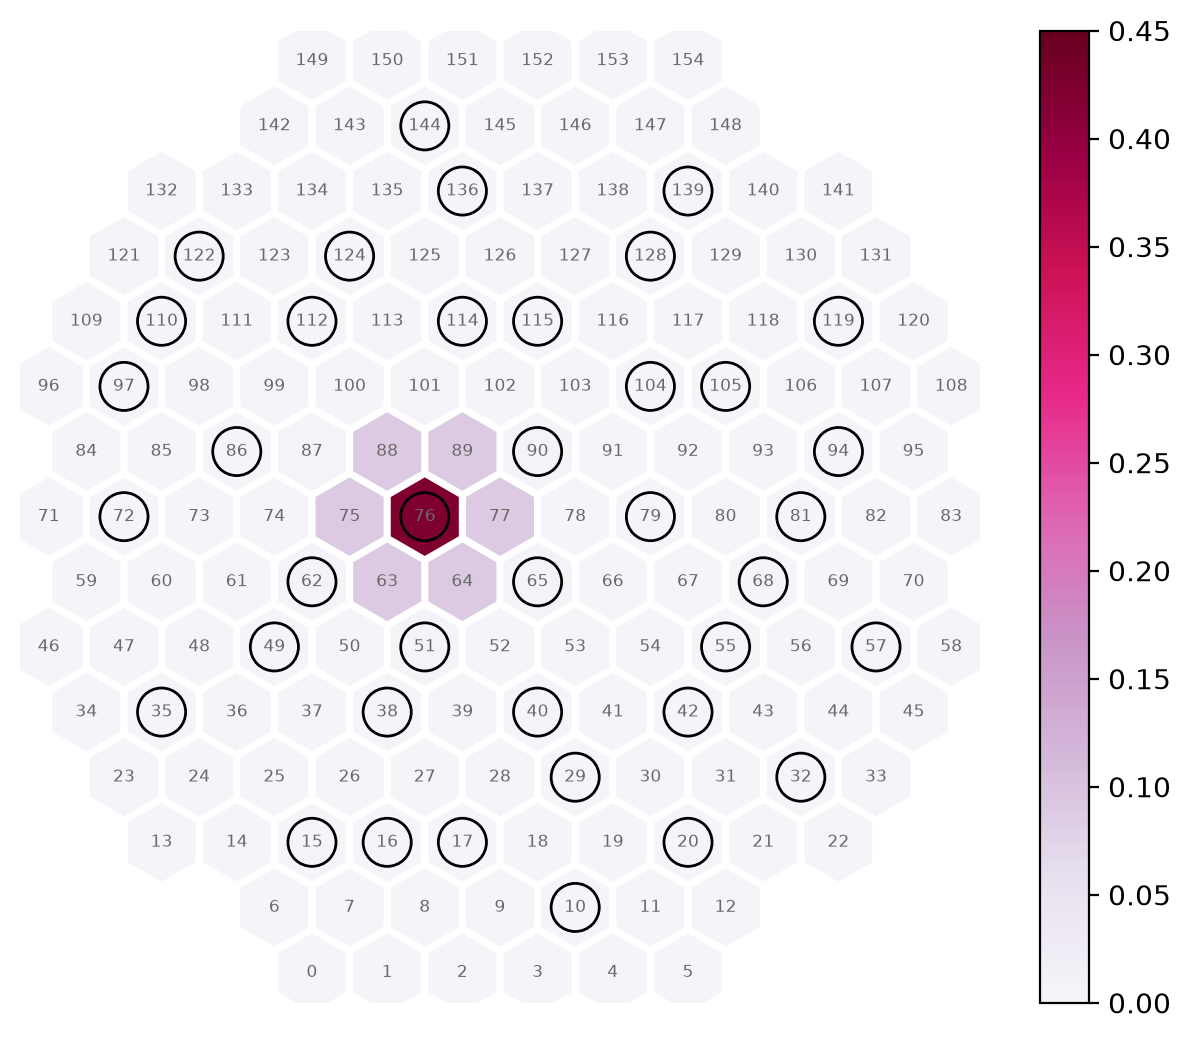

In [227]:
# # prep
# mouse_id, rot_id = 3, 0
# s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[(1,mouse_id,rot_id)]
# s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(6.3,5.3), dpi=200)
# plt.title(f'mouse {mouse_id}, sessions: {2}; top half occupied: {len(s_top)} tiles')

# map
plt.scatter(hex_0_all, hex_1_all, c=L_tile[76], cmap='PuRd', marker='h', s=800, vmin=0, vmax=.45, edgecolor='none')
plt.colorbar()

# plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')

plt.scatter(hex_0_all, hex_1_all, c='none', marker='o', s=n_edges_map*300, edgecolor='k')
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')

# setting
plt.axis('off')
plt.axis('equal')
plt.tight_layout()

In [242]:
np.where(L_tile==L_tile.max())

(array([0, 5]), array([0, 5]))

In [234]:
p.max()

0.5988941718104083

In [237]:
p = L_tile[s_top,:]

In [247]:
s_top

array([ 43, 121,  56, 131,  91, 120,  39, 106,  42,  77,  95,  93, 109,
       108,  90,  27,  45,  64,  52,  44,  84,  58, 118,  59, 141,  96,
        83,  33,  70, 140, 116, 130, 127, 147, 132, 104,  26,  80,  71,
       148,  78,  30, 143, 126,  72,  92,  28,  17,  54,  69,  85,  24,
        16,  41,  36,  67,  34,  55,  37, 117,  82, 103,   7,  98, 125,
        23,  19,  65,  46,  31, 113,  15,  25, 154, 142, 153,  11])

In [246]:
L_tile[1].max()

0.5279470922269486